# Phase 3.1 — Monte-Carlo simulator: what's the *distribution*, not just the mean?

**Driving question:** the points model gives E[points]; managers need the *shape* — floor, ceiling,
and the odds of a haul. Roll the components through the real scoring rules for a full distribution.

**What this stage must prove (internal correctness ONLY):** the sim mean reproduces the analytic
`full_pts` (a consistency check, not a predictive claim); clean sheet never co-occurs with a conceded
penalty (the shared team-GA draw). **Distributional *trust* is Phase 4.** Conditional on appearance
(no blank tail); single-player marginals (no team-stacking).

## Setup

In [ ]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from dal.pipeline import load as load_mart, run as run_pipeline
from dal.exceptions import MartNotBuiltError, MartSchemaError
from model.eval.walkforward import POSITIONS
try:
    loaded = load_mart()
except (MartNotBuiltError, MartSchemaError) as err:
    print(f'Rebuilding mart ({type(err).__name__})...'); run_pipeline(force=True); loaded = load_mart()
mart = loaded.mart
from model.simulate import simulate_from_mart
sim = simulate_from_mart(mart, n_sims=4000, seed=0)   # ~a few minutes
print(f'simulated player-GWs: {len(sim):,}')

## (a) Internal-correctness gate — does the sim mean reproduce the analytic points?

If the simulator is faithful, its per-row mean equals the composed `e_points` (`model.compose`) up to
Monte-Carlo error (and small saves-floor / bonus-clip nonlinearity). This is a *consistency* check, NOT
'sim predicts points'. **GK rows are excluded**: `compose` uses a robust GK `p60` that diverges from the
legacy flat-0.98 by design (spec §10.5), so the sim intentionally departs from it there.

In [ ]:
from model.compose import compose_points
ep = compose_points(mart)[['player_id','gw','e_points']]
s = sim.merge(ep, on=['player_id','gw']).dropna(subset=['sim_mean','e_points'])
s = s[s['position']!='GK']   # GK diverges by design (robust p60 vs legacy flat-0.98)
corr=np.corrcoef(s['sim_mean'],s['e_points'])[0,1]
fig,ax=plt.subplots(figsize=(4.5,4.5))
ax.scatter(s['e_points'],s['sim_mean'],s=4,alpha=0.2)
lim=[0,max(s['e_points'].max(),s['sim_mean'].max())]; ax.plot(lim,lim,'r--',lw=1)
ax.set_xlabel('analytic e_points (non-GK)'); ax.set_ylabel('simulated mean'); ax.set_title(f'consistency: corr={corr:.4f}')
plt.tight_layout(); plt.show()

## (b) The distribution profile + haul odds, per position

Floor (p10), median (p50), ceiling (p90), and **P(haul >= 10)** by position — the quantities a point
forecast can't express.

,p10,p50,sim_mean,p90,p_haul
position,,,,,
GK,1.006,2.807,4.278,7.959,0.075
DEF,0.629,2.228,3.436,7.795,0.039
MID,1.256,2.003,2.929,6.278,0.021
FWD,1.168,1.711,2.573,6.171,0.021


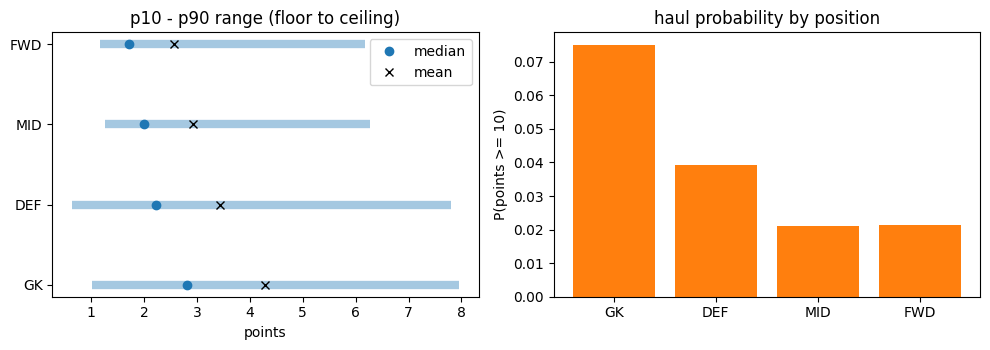

GK highest P(haul): clean sheet + saves + bonus can stack.


In [3]:
prof=sim.groupby('position')[['p10','p50','sim_mean','p90','p_haul']].mean().reindex(POSITIONS)
display(prof.round(3))
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(10,3.6))
y=np.arange(len(POSITIONS))
ax1.hlines(y,prof['p10'],prof['p90'],color='#1f77b4',lw=6,alpha=0.4)
ax1.plot(prof['p50'],y,'o',color='#1f77b4',label='median')
ax1.plot(prof['sim_mean'],y,'x',color='k',label='mean')
ax1.set_yticks(y); ax1.set_yticklabels(POSITIONS); ax1.set_xlabel('points'); ax1.legend()
ax1.set_title('p10 - p90 range (floor to ceiling)')
ax2.bar(POSITIONS, prof['p_haul'], color='#ff7f0e'); ax2.set_ylabel('P(points >= 10)')
ax2.set_title('haul probability by position')
plt.tight_layout(); plt.show()
print('GK highest P(haul): clean sheet + saves + bonus can stack.')

## Summary — Phase 3.1 verdict

**Proven (internal correctness):** sim mean vs analytic `e_points` (non-GK) corr ~0.999; CS never co-occurs
with a conceded penalty; reproducible under seed. We now have floor/ceiling/haul-odds per player.

**Not proven:** whether P(haul)=X% actually happens X% of the time — that is **Phase 4** (PIT / reliability
/ CRPS). **Carried limits:** no blank/`P(play)` tail (Phase 5), single-player only (no team-stacking); GK
consistency departs from the legacy sim by design (compose's robust `p60`, spec §10.5).